# Partie 1 — Ensemble Learning & Boosting

## 1. Étude théorique : Ensemble Learning

### Définition
L'**Ensemble Learning** consiste à combiner plusieurs modèles d'apprentissage (appelés *apprenants faibles* ou *weak learners*) pour produire un modèle global plus performant qu'aucun des modèles pris isolément.

### Fondement théorique : le biais et la variance
L'erreur de généralisation d'un modèle peut se décomposer en :

$$\text{Erreur} = \text{Biais}^2 + \text{Variance} + \text{Bruit irréductible}$$

- **Biais** : erreur due à des hypothèses trop simplistes (sous-apprentissage)
- **Variance** : erreur due à la sensibilité excessive aux données d'entraînement (sur-apprentissage)

Les méthodes d'ensemble agissent différemment sur ce compromis :

| Famille | Parallèle/Séquentiel | Réduit | Exemple |
|---|---|---|---|
| **Bagging** | Parallèle | Variance | Random Forest |
| **Boosting** | Séquentiel | Biais | AdaBoost, Gradient Boosting |
| **Stacking** | Parallèle + meta-modèle | Les deux | StackingClassifier |

### 1.1 Bagging (Bootstrap Aggregating)
- Entraîne `T` modèles **indépendants** sur des sous-échantillons tirés avec remise (bootstrap)
- Agrégation par **vote majoritaire** (classification) ou **moyenne** (régression)
- Réduit la variance car la moyenne de modèles instables est plus stable

### 1.2 Boosting
- Entraîne des modèles de manière **séquentielle**
- Chaque nouveau modèle se concentre sur les **erreurs** du précédent
- Réduit le biais en améliorant itérativement les zones mal apprises

### 1.3 Stacking
- Les prédictions des modèles de base deviennent les **features** d'un méta-modèle
- Le méta-modèle apprend à combiner les prédictions de manière optimale

---

## 2. Étude théorique : AdaBoost (Adaptive Boosting)

### Principe
AdaBoost est l'algorithme de boosting fondateur (Freund & Schapire, 1997). Il combine des **stumps de décision** (arbres de profondeur 1) en leur assignant des poids proportionnels à leur précision.

### Algorithme détaillé

**Initialisation :** Pour $N$ exemples, initialiser les poids $w_i = \frac{1}{N}$

**Pour chaque itération $t = 1, ..., T$ :**

1. Entraîner un classifieur faible $h_t$ sur les données pondérées par $w$

2. Calculer l'erreur pondérée :
$$\varepsilon_t = \sum_{i=1}^{N} w_i \cdot \mathbb{1}[h_t(x_i) \neq y_i]$$

3. Calculer le poids du classifieur (plus il est précis, plus son poids est élevé) :
$$\alpha_t = \frac{1}{2} \ln\left(\frac{1 - \varepsilon_t}{\varepsilon_t}\right)$$

4. Mettre à jour les poids (les exemples mal classés reçoivent plus de poids) :
$$w_i \leftarrow w_i \cdot \exp(-\alpha_t \cdot y_i \cdot h_t(x_i))$$

5. Normaliser : $w_i \leftarrow \frac{w_i}{\sum_j w_j}$

**Prédiction finale :** $H(x) = \text{sign}\left(\sum_{t=1}^{T} \alpha_t \cdot h_t(x)\right)$

### Intuition clé
- Si $\varepsilon_t < 0.5$ → $\alpha_t > 0$ → le classifieur contribue positivement
- Si $\varepsilon_t = 0.5$ → $\alpha_t = 0$ → le classifieur n'apporte rien (aléatoire)
- Si $\varepsilon_t > 0.5$ → $\alpha_t < 0$ → le classifieur inverse sa prédiction (!)  

Les exemples difficiles à classer voient leur poids augmenter à chaque itération : les classifieurs suivants sont **forcés** de s'y intéresser.

---
## 3. Implémentation Python

### 3.1 Chargement et exploration des données

On utilise le dataset **Breast Cancer** de sklearn :
- 569 échantillons, 30 features
- Tâche : classer une tumeur en **maligne (0)** ou **bénigne (1)**
- C'est un bon cas d'usage pour le boosting : données réelles avec frontière de décision non-triviale

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Chargement
data = load_breast_cancer()
X, y = data.data, data.target

# AdaBoost attend y ∈ {-1, +1} pour notre implémentation from scratch
y_adaboost = np.where(y == 0, -1, 1)

# Split train/test (80/20, stratifié pour garder la proportion de classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_adaboost, test_size=0.2, random_state=42, stratify=y_adaboost
)

print(f"Taille train : {X_train.shape}, test : {X_test.shape}")
print(f"Distribution des classes (train) : {np.bincount(y_train + 1)}")
print(f"Features : {data.feature_names[:5]}... ({X.shape[1]} au total)")

Taille train : (455, 30), test : (114, 30)
Distribution des classes (train) : [170   0 285]
Features : ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']... (30 au total)


### 3.2 Implémentation d'AdaBoost from scratch

On va implémenter AdaBoost **à la main** pour bien comprendre chaque étape.  
Le classifieur faible utilisé est un **Decision Stump** : arbre de profondeur 1 qui teste un seul seuil sur une seule feature.

**Pourquoi un stump ?**  
Il est légèrement meilleur que le hasard (≈ 60-70% d'accuracy) — c'est exactement ce qu'AdaBoost requiert.

In [2]:
class DecisionStump:
    """
    Classifieur faible : teste UN seuil sur UNE feature.
    Cherche le seuil qui minimise l'erreur pondérée.
    """
    def __init__(self):
        self.feature_index = None   # quelle feature on teste
        self.threshold = None       # valeur du seuil
        self.polarity = 1           # direction de la règle (+1 ou -1)
        self.alpha = None           # poids de ce stump dans l'ensemble

    def predict(self, X):
        n_samples = X.shape[0]
        X_col = X[:, self.feature_index]
        predictions = np.ones(n_samples)  # on commence avec tout à +1
        
        # La règle : si polarity=1, prédit -1 quand x < seuil
        if self.polarity == 1:
            predictions[X_col < self.threshold] = -1
        else:
            predictions[X_col >= self.threshold] = -1
        
        return predictions


class AdaBoostScratch:
    """
    Implémentation d'AdaBoost pour la classification binaire.
    Labels attendus : y ∈ {-1, +1}
    """
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.stumps = []  # liste des classifieurs faibles
        # Pour suivre l'évolution de l'entraînement :
        self.training_errors = []
        self.stump_errors = []
        self.alphas = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Étape 1 : initialiser les poids uniformément
        weights = np.ones(n_samples) / n_samples

        for t in range(self.n_estimators):
            stump = DecisionStump()
            min_error = float('inf')

            # Étape 2 : chercher le meilleur stump (feature + seuil + polarité)
            for feature_i in range(n_features):
                X_col = X[:, feature_i]
                thresholds = np.unique(X_col)  # tous les seuils possibles

                for threshold in thresholds:
                    for polarity in [1, -1]:
                        predictions = np.ones(n_samples)
                        if polarity == 1:
                            predictions[X_col < threshold] = -1
                        else:
                            predictions[X_col >= threshold] = -1

                        # Erreur pondérée : somme des poids des exemples mal classés
                        error = np.sum(weights[y != predictions])

                        if error < min_error:
                            min_error = error
                            stump.feature_index = feature_i
                            stump.threshold = threshold
                            stump.polarity = polarity

            # Étape 3 : calculer α (poids du stump dans l'ensemble)
            # Clip pour éviter log(0) si erreur = 0 ou 1
            eps = 1e-10
            alpha = 0.5 * np.log((1 - min_error + eps) / (min_error + eps))
            stump.alpha = alpha

            # Étape 4 : mettre à jour les poids
            predictions = stump.predict(X)
            weights *= np.exp(-alpha * y * predictions)

            # Étape 5 : normaliser
            weights /= np.sum(weights)

            self.stumps.append(stump)
            self.stump_errors.append(min_error)
            self.alphas.append(alpha)

            # Suivi de l'erreur globale à cet instant
            train_preds = self.predict(X)
            train_error = 1 - accuracy_score(y, train_preds)
            self.training_errors.append(train_error)

        return self

    def predict(self, X):
        # Somme pondérée des prédictions de tous les stumps
        stump_preds = np.array([stump.alpha * stump.predict(X) for stump in self.stumps])
        return np.sign(np.sum(stump_preds, axis=0))


print("Classes définies. Entraînement en cours...")

Classes définies. Entraînement en cours...


In [3]:
# Entraînement (peut prendre ~30 secondes selon la machine)
ada_scratch = AdaBoostScratch(n_estimators=50)
ada_scratch.fit(X_train, y_train)

# Évaluation
y_pred_scratch = ada_scratch.predict(X_test)
acc_scratch = accuracy_score(y_test, y_pred_scratch)
print(f"Accuracy AdaBoost from scratch : {acc_scratch:.4f} ({acc_scratch*100:.2f}%)")

Accuracy AdaBoost from scratch : 0.9561 (95.61%)


### 3.3 Comparaison avec sklearn

sklearn implémente la même logique mais de manière optimisée.  
On l'utilise ici pour valider notre implémentation et comparer.

In [4]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Labels sklearn : y ∈ {0, 1} (pas {-1, +1})
X_train_sk, X_test_sk, y_train_sk, y_test_sk = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# AdaBoost sklearn avec un stump (arbre de profondeur 1)
ada_sklearn = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)
ada_sklearn.fit(X_train_sk, y_train_sk)

y_pred_sklearn = ada_sklearn.predict(X_test_sk)
acc_sklearn = accuracy_score(y_test_sk, y_pred_sklearn)

print(f"Accuracy AdaBoost from scratch : {acc_scratch*100:.2f}%")
print(f"Accuracy AdaBoost sklearn      : {acc_sklearn*100:.2f}%")
print()
print("Rapport détaillé (sklearn) :")
print(classification_report(y_test_sk, y_pred_sklearn, target_names=data.target_names))

Accuracy AdaBoost from scratch : 95.61%
Accuracy AdaBoost sklearn      : 95.61%

Rapport détaillé (sklearn) :
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 3.4 Visualisations — Comprendre ce qui se passe

#### Évolution de l'erreur d'entraînement
On observe comment l'erreur diminue au fil des itérations.

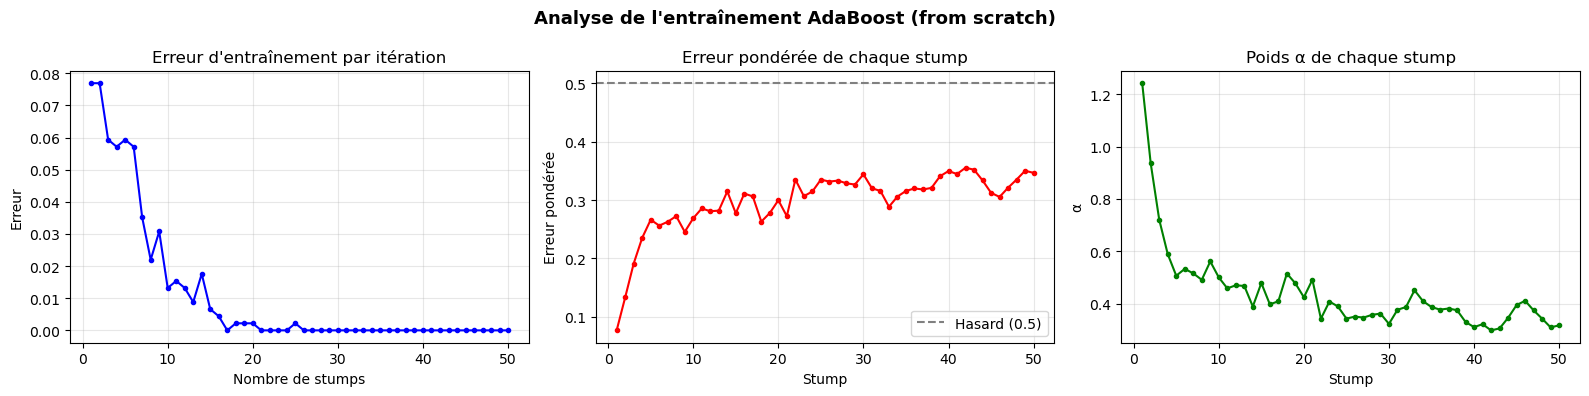

Figure sauvegardée : adaboost_training.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

iterations = range(1, len(ada_scratch.training_errors) + 1)

# Graphe 1 : erreur d'entraînement au fil des itérations
axes[0].plot(iterations, ada_scratch.training_errors, 'b-o', markersize=3)
axes[0].set_title("Erreur d'entraînement par itération")
axes[0].set_xlabel("Nombre de stumps")
axes[0].set_ylabel("Erreur")
axes[0].grid(True, alpha=0.3)

# Graphe 2 : erreur de chaque stump individuel
axes[1].plot(iterations, ada_scratch.stump_errors, 'r-o', markersize=3)
axes[1].axhline(y=0.5, color='gray', linestyle='--', label='Hasard (0.5)')
axes[1].set_title("Erreur pondérée de chaque stump")
axes[1].set_xlabel("Stump")
axes[1].set_ylabel("Erreur pondérée")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Graphe 3 : alpha (poids) de chaque stump
axes[2].plot(iterations, ada_scratch.alphas, 'g-o', markersize=3)
axes[2].set_title("Poids α de chaque stump")
axes[2].set_xlabel("Stump")
axes[2].set_ylabel("α")
axes[2].grid(True, alpha=0.3)

plt.suptitle("Analyse de l'entraînement AdaBoost (from scratch)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('adaboost_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : adaboost_training.png")

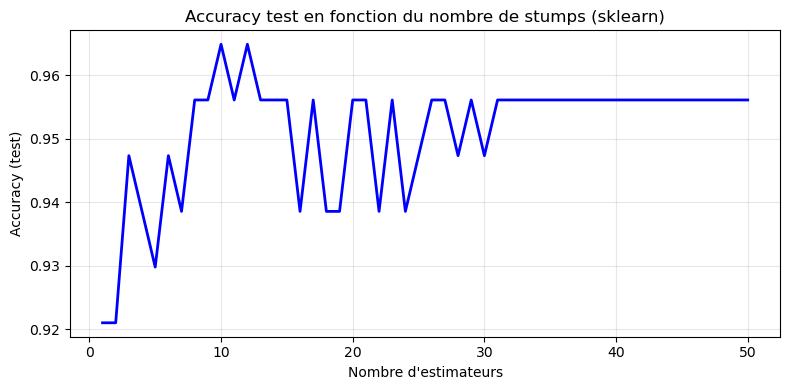

In [6]:
# Accuracy sklearn en fonction du nombre d'estimateurs (staged_predict)
staged_accuracies = [
    accuracy_score(y_test_sk, y_pred)
    for y_pred in ada_sklearn.staged_predict(X_test_sk)
]

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(staged_accuracies) + 1), staged_accuracies, 'b-', linewidth=2)
plt.xlabel("Nombre d'estimateurs")
plt.ylabel("Accuracy (test)")
plt.title("Accuracy test en fonction du nombre de stumps (sklearn)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('adaboost_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Comparaison avec d'autres méthodes d'Ensemble Learning

Pour mettre en perspective AdaBoost dans la famille Ensemble Learning.

Decision Tree (seul)           : 91.23%
Bagging                        : 93.86%
Random Forest                  : 95.61%
AdaBoost                       : 95.61%
Gradient Boosting              : 94.74%


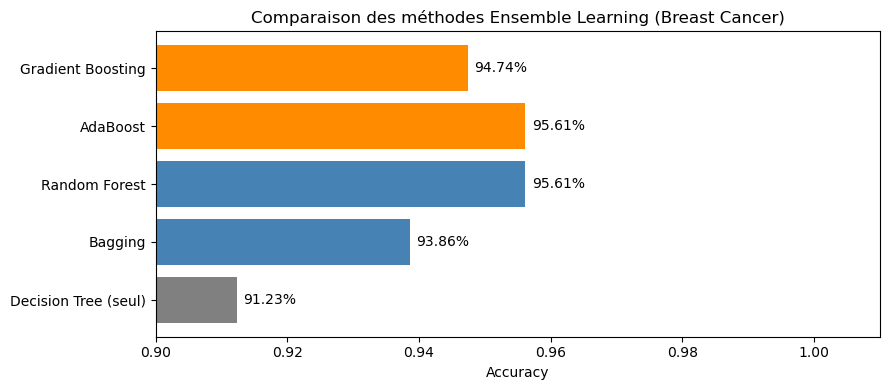


Note : bleu = Bagging famille | orange = Boosting famille


In [7]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Decision Tree (seul)": DecisionTreeClassifier(random_state=42),
    "Bagging": BaggingClassifier(n_estimators=50, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_sk, y_train_sk)
    acc = accuracy_score(y_test_sk, model.predict(X_test_sk))
    results[name] = acc
    print(f"{name:<30} : {acc*100:.2f}%")

# Visualisation
plt.figure(figsize=(9, 4))
bars = plt.barh(list(results.keys()), list(results.values()), color=['gray', 'steelblue', 'steelblue', 'darkorange', 'darkorange'])
plt.xlabel('Accuracy')
plt.title('Comparaison des méthodes Ensemble Learning (Breast Cancer)')
plt.xlim(0.9, 1.01)
for bar, val in zip(bars, results.values()):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val*100:.2f}%', va='center')
plt.tight_layout()
plt.savefig('comparaison_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote : bleu = Bagging famille | orange = Boosting famille")

## 4. Synthèse

### Ce qu'on a démontré

1. **L'Ensemble Learning surpasse un modèle seul** : l'arbre de décision isolé est systématiquement inférieur aux méthodes d'ensemble.

2. **AdaBoost converge rapidement** : l'erreur d'entraînement chute dès les premières itérations, grâce à la repondération des exemples difficiles.

3. **Les stumps individuels restent faibles** : leur erreur pondérée est légèrement inférieure à 0.5 — c'est suffisant. AdaBoost en fait un ensemble fort.

4. **Le Boosting réduit le biais** : en corrigeant itérativement les erreurs, AdaBoost et Gradient Boosting atteignent des performances proches de l'optimal.

### Limites d'AdaBoost
- Sensible aux **outliers** (les exemples aberrants reçoivent des poids très élevés)
- Moins efficace si le bruit dans les labels est élevé
- Gradient Boosting est généralement plus performant car il optimise une fonction de perte différentiable

### Pour aller plus loin
- **Gradient Boosting** : généralisation qui optimise n'importe quelle fonction de perte par descente de gradient
- **XGBoost / LightGBM** : implémentations ultra-optimisées utilisées en compétition ML